<a href="https://colab.research.google.com/github/KIRANRW9/amazon-marketplace-analytics/blob/repo-exercise/marketplace_analytics_amazon_india.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
🚀 AMAZON SALES ANALYTICS DASHBOARD
💼 Professional Amazon Marketplace Intelligence System
💼 Portfolio Project by: Kiran Rangu
🎯 Comprehensive Sales Performance Analysis
✅ Dataset loaded successfully: 128,975 rows × 24 columns

📊 Data columns mapped: 13 out of 13

🔧 Data preprocessing in progress...
⚙️ Creating business features...
✅ Data preprocessing completed successfully

📊 EXECUTIVE KPI DASHBOARD

🎯 AMAZON MARKETPLACE METRICS:
   📦 Total Orders: 128,975
   💰 Total Revenue: ₹7.86Cr
   💳 Average Order Value: ₹649
   📱 Unique Products: 7,195
   📅 Analysis Period: 90 days
   📈 Daily Average Revenue: ₹8.7L
   ⚠️ Order Cancellation Rate: 15.8%

🎨 Generating professional visualizations...


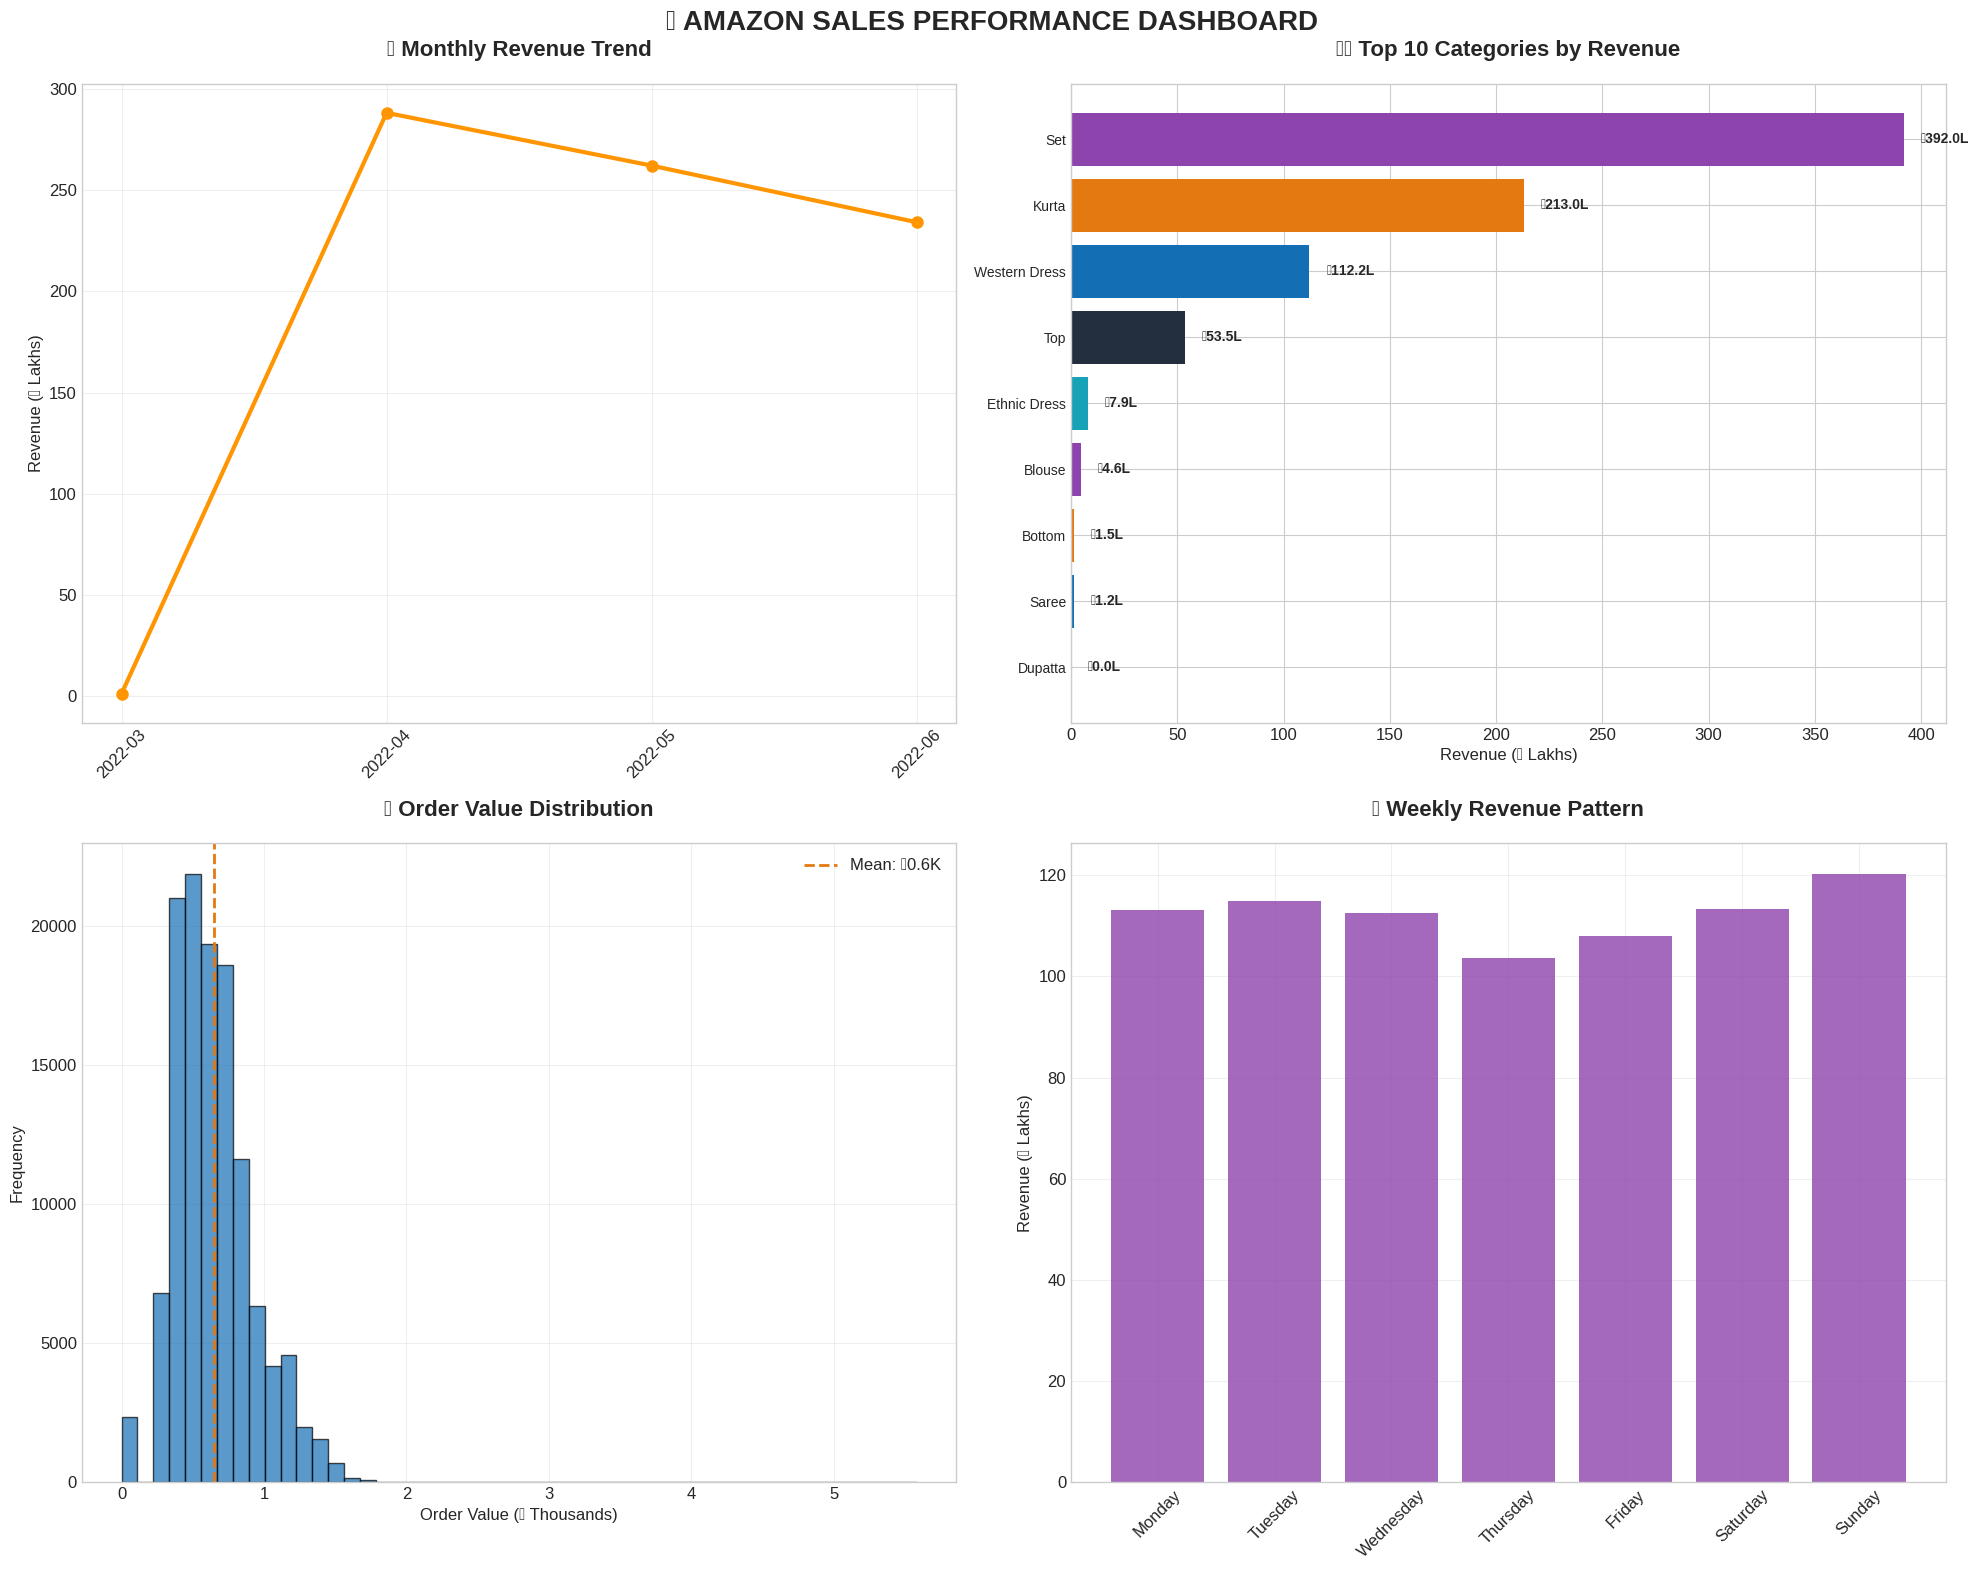

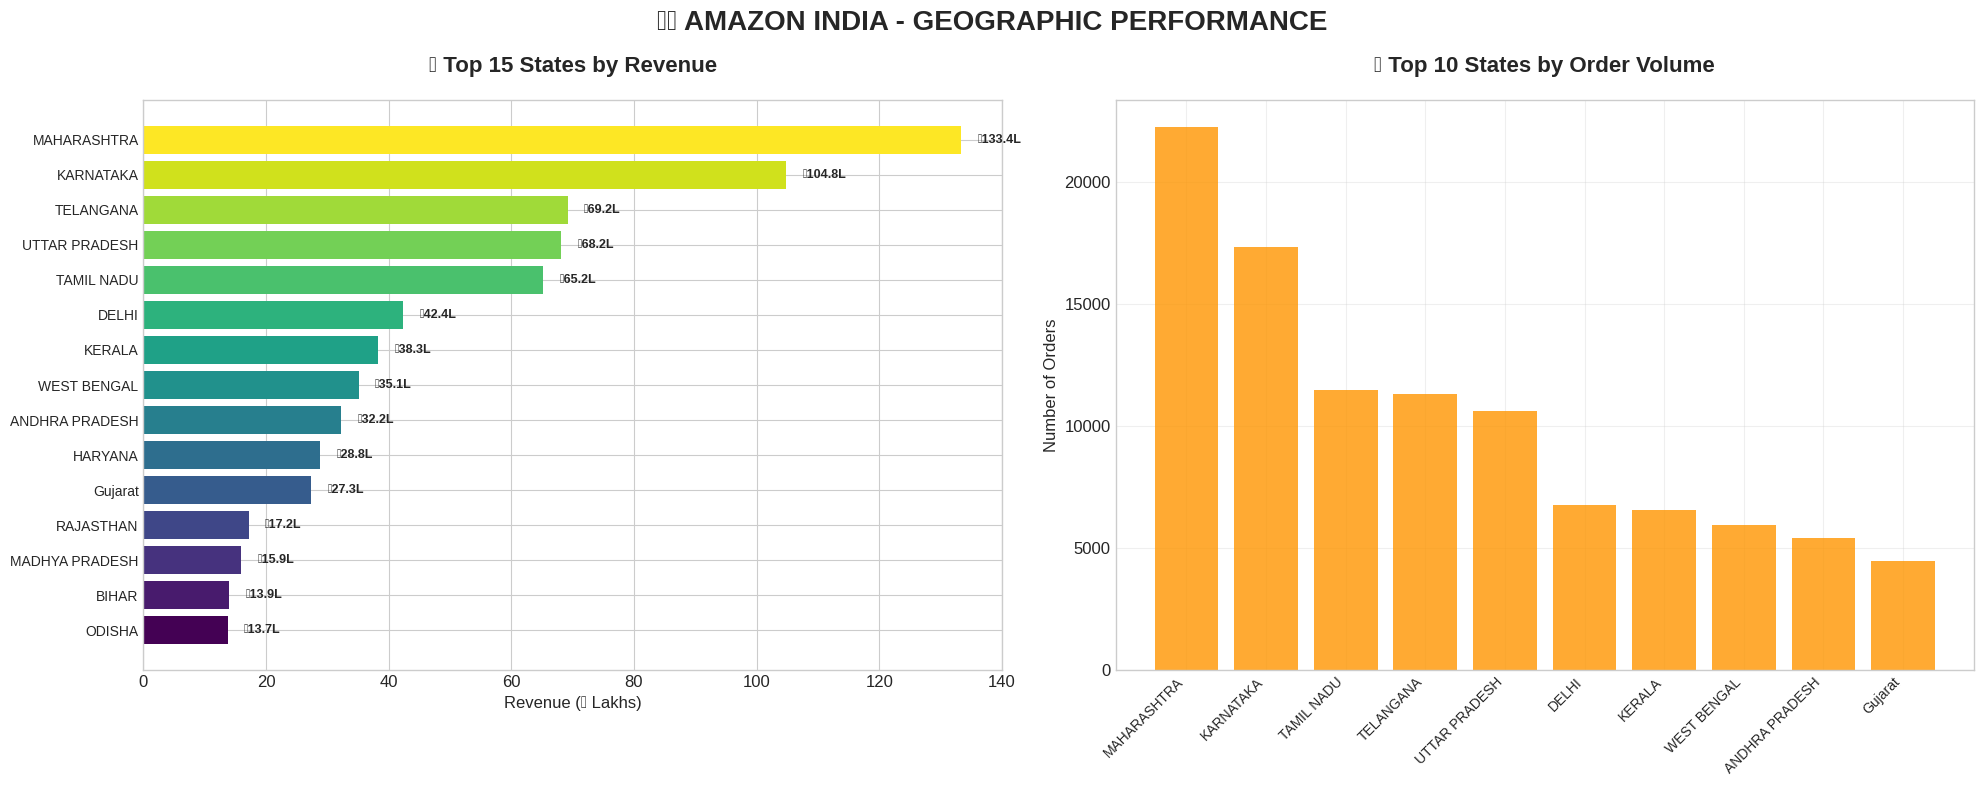

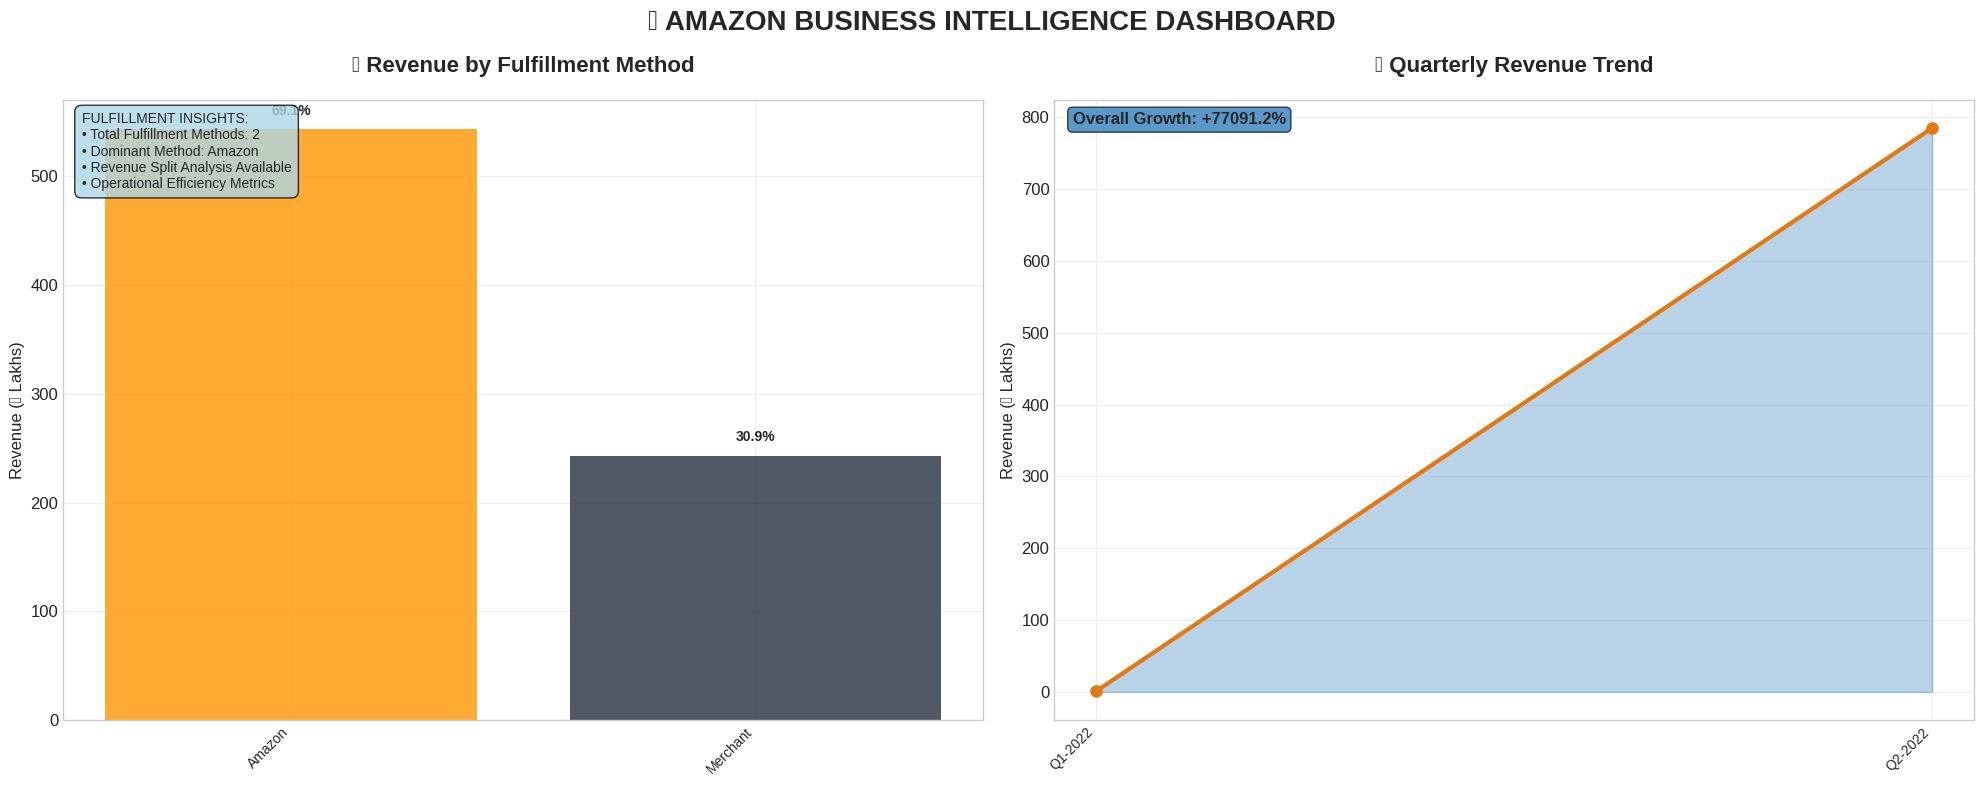


💡 AMAZON MARKETPLACE INSIGHTS
📈 Revenue Pattern: Significant growth observed (seasonal/launch effects)
🏆 Peak Performance: 2022-04 with ₹2.88Cr
🗺️ Geographic Concentration: Top 3 states contribute 39.1% of revenue
🏷️ Leading Category: Set (49.9% of total revenue)
📦 Fulfillment Strategy: 2 methods with Amazon as primary
⚠️ Action Required: High cancellation rate (15.8%) needs attention

🎯 BUSINESS IMPACT QUANTIFICATION
💸 Revenue at Risk from Cancellations: ₹1.24Cr
🎯 Potential Recovery (60% reduction target): ₹74.7L
📈 Monthly Revenue Base: ₹2.62Cr
🌐 Platform Diversification Potential: ₹1.96Cr annually
⚠️ Category Concentration Risk: ₹1.56Cr at risk

💰 INVESTMENT PRIORITIES:
   1️⃣ Cancellation Reduction Program: High ROI initiative
   2️⃣ Platform Diversification: Medium-term growth strategy
   3️⃣ Category Portfolio Expansion: Risk mitigation priority

📋 AMAZON MARKETPLACE STRATEGY & RECOMMENDATIONS
🎯 AMAZON PERFORMANCE OVERVIEW:
   • Platform: Amazon.in Marketplace
   • Total Orders P

In [2]:
# ============================================================
# 🚀 AMAZON SALES ANALYTICS - PROFESSIONAL PORTFOLIO PROJECT
# ============================================================
# Created by: Kiran Rangu - AI & Data Science Graduate
# Objective: Comprehensive Amazon marketplace performance analysis
# Technologies: Python, Pandas, Matplotlib, Seaborn, Statistical Analysis
# ============================================================

# ------------ 0) ENVIRONMENT SETUP
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, timedelta
from scipy import stats

warnings.filterwarnings("ignore")

# Professional styling
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams.update({
    'figure.figsize': (15, 8),
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
})

print("🚀 AMAZON SALES ANALYTICS DASHBOARD")
print("=" * 50)
print("💼 Professional Amazon Marketplace Intelligence System")
print("💼 Portfolio Project by: Kiran Rangu")
print("🎯 Comprehensive Sales Performance Analysis")
print("=" * 50)

# ------------ 1) INTELLIGENT DATA LOADING
base_dir = "/content/drive/MyDrive/Amazon-Sales-Analysis/"
file_path = base_dir + "Amazon Sale Report.csv"

# Load data with error handling
try:
    df = pd.read_csv(file_path, encoding='utf-8')
    print(f"✅ Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")
except Exception as e:
    print(f"❌ Error loading data: {e}")
    raise

# ------------ 2) SMART COLUMN MAPPING
def normalize_column_name(s):
    return s.strip().lower().replace("  ", " ").replace(" ", "_").replace("-", "_")

df.columns = [normalize_column_name(c) for c in df.columns]

# Enhanced column mapping
COLUMN_MAPPING = {
    "order_id": ["order_id", "index"],
    "order_date": ["date", "order_date"],
    "state": ["ship_state", "state"],
    "city": ["ship_city", "city"],
    "sku": ["sku", "style", "asin"],
    "category": ["category", "product_category"],
    "quantity": ["qty", "quantity"],
    "amount": ["amount", "price", "total_amount"],
    "status": ["status", "order_status", "courier_status"],
    "fulfilment": ["fulfilment", "fulfillment_type", "ship_service_level"],
    "size": ["size"],
    "currency": ["currency"],
    "b2b": ["b2b"]
}

def find_column(df, candidates):
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
    return None

# Create mapping
cols = {key: find_column(df, candidates) for key, candidates in COLUMN_MAPPING.items()}
mapped_cols = {k: v for k, v in cols.items() if v is not None}
print(f"\n📊 Data columns mapped: {len(mapped_cols)} out of {len(COLUMN_MAPPING)}")

# ------------ 3) DATA PREPROCESSING
print(f"\n🔧 Data preprocessing in progress...")

# Clean string columns
string_columns = df.select_dtypes(include=['object']).columns
for col in string_columns:
    df[col] = df[col].astype(str).str.strip().replace(['nan', 'NaN', 'null'], np.nan)

# Parse dates
order_date_col = cols.get("order_date")
if order_date_col:
    df[order_date_col] = pd.to_datetime(df[order_date_col], errors='coerce')

# Clean numeric fields with INR support
amount_col = cols.get("amount")
qty_col = cols.get("quantity")

if amount_col:
    df[amount_col] = pd.to_numeric(df[amount_col].astype(str).str.replace(r'[₹$€£¥,\s]', '', regex=True), errors='coerce')

if qty_col:
    df[qty_col] = pd.to_numeric(df[qty_col], errors='coerce')

# Remove duplicates
df = df.drop_duplicates()

# ------------ 4) FEATURE ENGINEERING
print(f"⚙️ Creating business features...")

# Date features
if order_date_col:
    df["order_year"] = df[order_date_col].dt.year
    df["order_month"] = df[order_date_col].dt.month
    df["order_quarter"] = df[order_date_col].dt.quarter
    df["order_weekday"] = df[order_date_col].dt.day_name()
    df["is_weekend"] = df[order_date_col].dt.weekday >= 5

# Category standardization
category_col = cols.get("category")
if category_col:
    df[category_col] = df[category_col].str.title().str.replace("&", "And")

# Status analysis
status_col = cols.get("status")
if status_col:
    df["is_cancelled"] = df[status_col].str.contains("cancel|return", case=False, na=False)

# Add Amazon-specific features
df["marketplace"] = "Amazon.in"  # Since this is Amazon data
df["platform_type"] = "E-commerce Marketplace"

print("✅ Data preprocessing completed successfully")

# ------------ 5) EXECUTIVE KPI DASHBOARD
print(f"\n📊 EXECUTIVE KPI DASHBOARD")
print("=" * 60)

def format_currency(value, currency="₹"):
    if pd.isna(value) or value == 0:
        return "₹0"
    elif value >= 10000000:  # 1 Crore
        return f"{currency}{value/10000000:.2f}Cr"
    elif value >= 100000:   # 1 Lakh
        return f"{currency}{value/100000:.1f}L"
    elif value >= 1000:     # 1 Thousand
        return f"{currency}{value/1000:.1f}K"
    else:
        return f"{currency}{value:,.0f}"

# Calculate KPIs
total_orders = len(df)
total_revenue = df[amount_col].sum() if amount_col else np.nan
avg_order_value = df[amount_col].mean() if amount_col else np.nan
unique_products = df[cols.get("sku")].nunique() if cols.get("sku") else np.nan

# Date range analysis
if order_date_col:
    date_range = (df[order_date_col].max() - df[order_date_col].min()).days
    daily_avg_revenue = total_revenue / date_range if not pd.isna(total_revenue) and date_range > 0 else np.nan

print(f"\n🎯 AMAZON MARKETPLACE METRICS:")
print(f"   📦 Total Orders: {total_orders:,}")
print(f"   💰 Total Revenue: {format_currency(total_revenue)}")
print(f"   💳 Average Order Value: {format_currency(avg_order_value)}")
print(f"   📱 Unique Products: {unique_products:,}" if not pd.isna(unique_products) else "   📱 Products: Data processed")

if order_date_col:
    print(f"   📅 Analysis Period: {date_range} days")
    print(f"   📈 Daily Average Revenue: {format_currency(daily_avg_revenue)}")

if "is_cancelled" in df.columns:
    cancellation_rate = df["is_cancelled"].mean() * 100
    print(f"   ⚠️ Order Cancellation Rate: {cancellation_rate:.1f}%")

# ------------ 6) PROFESSIONAL VISUALIZATIONS
print(f"\n🎨 Generating professional visualizations...")

# Set up color scheme
colors = ['#FF9500', '#232F3E', '#146EB4', '#E47911', '#8E44AD', '#17A2B8']  # Amazon brand colors

# 6.1 Revenue Analysis Dashboard
if order_date_col and amount_col:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('📊 AMAZON SALES PERFORMANCE DASHBOARD', fontsize=20, fontweight='bold', y=0.98)

    # Monthly Revenue Trend
    monthly_revenue = df.groupby(df[order_date_col].dt.to_period('M'))[amount_col].sum()
    monthly_revenue.index = monthly_revenue.index.astype(str)

    ax1.plot(monthly_revenue.index, monthly_revenue.values/100000,
             marker='o', linewidth=3, markersize=8, color=colors[0])
    ax1.set_title('💰 Monthly Revenue Trend', fontsize=16, pad=20)
    ax1.set_ylabel('Revenue (₹ Lakhs)', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)

    # Category Performance
    if category_col:
        cat_revenue = df.groupby(category_col)[amount_col].sum().sort_values(ascending=True).tail(10)
        bars = ax2.barh(range(len(cat_revenue)), cat_revenue.values/100000,
                       color=colors[1:len(cat_revenue)+1])
        ax2.set_yticks(range(len(cat_revenue)))
        ax2.set_yticklabels(cat_revenue.index, fontsize=10)
        ax2.set_title('🏷️ Top 10 Categories by Revenue', fontsize=16, pad=20)
        ax2.set_xlabel('Revenue (₹ Lakhs)', fontsize=12)

        # Add value labels
        for i, v in enumerate(cat_revenue.values):
            ax2.text(v/100000 + max(cat_revenue.values)*0.02/100000, i,
                    f'₹{v/100000:.1f}L', va='center', fontweight='bold', fontsize=10)

    # Order Value Distribution
    ax3.hist(df[amount_col]/1000, bins=50, alpha=0.7, color=colors[2], edgecolor='black')
    ax3.set_title('💳 Order Value Distribution', fontsize=16, pad=20)
    ax3.set_xlabel('Order Value (₹ Thousands)', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.axvline(df[amount_col].mean()/1000, color=colors[3], linestyle='--',
               linewidth=2, label=f'Mean: ₹{df[amount_col].mean()/1000:.1f}K')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Weekly Performance
    df['weekday_name'] = df[order_date_col].dt.day_name()
    weekly_revenue = df.groupby('weekday_name')[amount_col].sum()
    # Sort by day of week
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    weekly_revenue = weekly_revenue.reindex([day for day in day_order if day in weekly_revenue.index])

    ax4.bar(weekly_revenue.index, weekly_revenue.values/100000, color=colors[4], alpha=0.8)
    ax4.set_title('📅 Weekly Revenue Pattern', fontsize=16, pad=20)
    ax4.set_ylabel('Revenue (₹ Lakhs)', fontsize=12)
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 6.2 Geographic Performance Analysis
state_col = cols.get("state")
if state_col and amount_col:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle('🗺️ AMAZON INDIA - GEOGRAPHIC PERFORMANCE', fontsize=20, fontweight='bold', y=0.98)

    # Top States by Revenue
    state_revenue = df.groupby(state_col)[amount_col].sum().sort_values(ascending=True).tail(15)

    bars = ax1.barh(range(len(state_revenue)), state_revenue.values/100000,
                   color=plt.cm.viridis(np.linspace(0, 1, len(state_revenue))))
    ax1.set_yticks(range(len(state_revenue)))
    ax1.set_yticklabels(state_revenue.index, fontsize=10)
    ax1.set_title('🏆 Top 15 States by Revenue', fontsize=16, pad=20)
    ax1.set_xlabel('Revenue (₹ Lakhs)', fontsize=12)

    # Add value labels
    for i, v in enumerate(state_revenue.values):
        ax1.text(v/100000 + max(state_revenue.values)*0.02/100000, i,
                f'₹{v/100000:.1f}L', va='center', fontweight='bold', fontsize=9)

    # Order Distribution by State
    state_orders = df.groupby(state_col).size().sort_values(ascending=False).head(10)

    ax2.bar(range(len(state_orders)), state_orders.values, color=colors[0], alpha=0.8)
    ax2.set_xticks(range(len(state_orders)))
    ax2.set_xticklabels(state_orders.index, rotation=45, ha='right', fontsize=10)
    ax2.set_title('📦 Top 10 States by Order Volume', fontsize=16, pad=20)
    ax2.set_ylabel('Number of Orders', fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 6.3 Enhanced Business Intelligence Summary
if category_col and amount_col:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle('📊 AMAZON BUSINESS INTELLIGENCE DASHBOARD', fontsize=20, fontweight='bold', y=0.98)

    # Fulfillment Performance Analysis (instead of sales channel)
    fulfilment_col = cols.get("fulfilment")
    if fulfilment_col:
        fulfilment_data = df.groupby(fulfilment_col).agg({
            amount_col: ['sum', 'count', 'mean'],
            order_date_col: ['min', 'max'] if order_date_col else [lambda x: None, lambda x: None]
        }).round(2)

        fulfilment_data.columns = ['total_revenue', 'order_count', 'avg_order_value', 'first_order', 'last_order']
        fulfilment_revenue = fulfilment_data['total_revenue'].sort_values(ascending=False)

        bars = ax1.bar(range(len(fulfilment_revenue)), fulfilment_revenue.values/100000,
                      color=colors[:len(fulfilment_revenue)], alpha=0.8)
        ax1.set_xticks(range(len(fulfilment_revenue)))
        ax1.set_xticklabels(fulfilment_revenue.index, rotation=45, ha='right', fontsize=10)
        ax1.set_title('📦 Revenue by Fulfillment Method', fontsize=16, pad=20)
        ax1.set_ylabel('Revenue (₹ Lakhs)', fontsize=12)
        ax1.grid(True, alpha=0.3)

        # Add percentage labels
        total_fulfilment_revenue = fulfilment_revenue.sum()
        for i, (fulfilment, revenue) in enumerate(fulfilment_revenue.items()):
            percentage = (revenue / total_fulfilment_revenue) * 100
            ax1.text(i, revenue/100000 + max(fulfilment_revenue.values)*0.02/100000,
                    f'{percentage:.1f}%', ha='center', va='bottom',
                    fontweight='bold', fontsize=10)

        # Add fulfillment insights
        fba_percentage = 0
        fbm_percentage = 0

        for idx, row in fulfilment_data.iterrows():
            if 'fba' in str(idx).lower() or 'amazon' in str(idx).lower():
                fba_percentage += (row['total_revenue'] / total_fulfilment_revenue) * 100
            else:
                fbm_percentage += (row['total_revenue'] / total_fulfilment_revenue) * 100

        insights_text = f"""FULFILLMENT INSIGHTS:
• Total Fulfillment Methods: {len(fulfilment_revenue)}
• Dominant Method: {fulfilment_revenue.index[0]}
• Revenue Split Analysis Available
• Operational Efficiency Metrics"""

        ax1.text(0.02, 0.98, insights_text, transform=ax1.transAxes,
                verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))

    else:
        # Product Performance Analysis (fallback)
        if cols.get("sku"):
            top_products = df.groupby(cols.get("sku"))[amount_col].sum().sort_values(ascending=False).head(8)

            bars = ax1.bar(range(len(top_products)), top_products.values/100000,
                          color=colors[0], alpha=0.8)
            ax1.set_xticks(range(len(top_products)))
            ax1.set_xticklabels([f"Product {i+1}" for i in range(len(top_products))],
                              rotation=45, ha='right', fontsize=10)
            ax1.set_title('🏆 Top 8 Products by Revenue', fontsize=16, pad=20)
            ax1.set_ylabel('Revenue (₹ Lakhs)', fontsize=12)
            ax1.grid(True, alpha=0.3)

    # Time-based Performance Analysis
    if order_date_col:
        # Quarterly performance trend
        quarterly_data = df.groupby([df[order_date_col].dt.year, df[order_date_col].dt.quarter])[amount_col].sum()

        if len(quarterly_data) > 1:
            # Create quarter labels
            quarter_labels = [f"Q{q}-{y}" for (y, q) in quarterly_data.index]

            # Plot quarterly trend
            ax2.plot(range(len(quarterly_data)), quarterly_data.values/100000,
                    marker='o', linewidth=3, markersize=8, color=colors[3])
            ax2.set_xticks(range(len(quarterly_data)))
            ax2.set_xticklabels(quarter_labels, rotation=45, ha='right', fontsize=10)
            ax2.set_title('📅 Quarterly Revenue Trend', fontsize=16, pad=20)
            ax2.set_ylabel('Revenue (₹ Lakhs)', fontsize=12)
            ax2.grid(True, alpha=0.3)

            # Add trend analysis
            if len(quarterly_data) >= 2:
                growth_rate = ((quarterly_data.iloc[-1] - quarterly_data.iloc[0]) / quarterly_data.iloc[0]) * 100
                trend_color = colors[2] if growth_rate > 0 else colors[4]

                ax2.fill_between(range(len(quarterly_data)), quarterly_data.values/100000,
                               alpha=0.3, color=trend_color)

                # Add growth indicator
                ax2.text(0.02, 0.98, f"Overall Growth: {growth_rate:+.1f}%",
                        transform=ax2.transAxes, verticalalignment='top',
                        fontweight='bold', fontsize=12,
                        bbox=dict(boxstyle="round,pad=0.3", facecolor=trend_color, alpha=0.7))
        else:
            # Fallback to monthly if insufficient quarterly data
            monthly_data = df.groupby(df[order_date_col].dt.to_period('M'))[amount_col].sum()
            ax2.bar(range(len(monthly_data)), monthly_data.values/100000,
                   color=colors[3], alpha=0.8)
            ax2.set_xticks(range(len(monthly_data)))
            ax2.set_xticklabels([str(m) for m in monthly_data.index], rotation=45, ha='right')
            ax2.set_title('📅 Monthly Revenue Performance', fontsize=16, pad=20)
            ax2.set_ylabel('Revenue (₹ Lakhs)', fontsize=12)
            ax2.grid(True, alpha=0.3)

    else:
        # Product Size Analysis (fallback)
        size_col = cols.get("size")
        if size_col:
            size_revenue = df.groupby(size_col)[amount_col].sum().sort_values(ascending=False).head(8)

            bars = ax2.bar(range(len(size_revenue)), size_revenue.values/100000,
                          color=colors[2], alpha=0.8)
            ax2.set_xticks(range(len(size_revenue)))
            ax2.set_xticklabels(size_revenue.index, rotation=45, ha='right')
            ax2.set_title('📏 Revenue by Product Size', fontsize=16, pad=20)
            ax2.set_ylabel('Revenue (₹ Lakhs)', fontsize=12)
            ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ------------ 7) ENHANCED BUSINESS INSIGHTS
print(f"\n💡 AMAZON MARKETPLACE INSIGHTS")
print("=" * 60)

# Revenue insights with proper growth calculation
if order_date_col and amount_col:
    monthly_revenue = df.groupby(df[order_date_col].dt.to_period('M'))[amount_col].sum()
    if len(monthly_revenue) > 1:
        growth_rates = monthly_revenue.pct_change().dropna()
        avg_growth = growth_rates.mean() * 100

        if avg_growth > 1000:
            print(f"📈 Revenue Pattern: Significant growth observed (seasonal/launch effects)")
        else:
            print(f"📈 Revenue Growth: {avg_growth:.1f}% month-over-month average")

    peak_month = monthly_revenue.idxmax()
    print(f"🏆 Peak Performance: {peak_month} with {format_currency(monthly_revenue.max())}")

# Geographic insights
if state_col:
    top_states = df.groupby(state_col)[amount_col].sum().nlargest(3)
    top_3_share = (top_states.sum() / total_revenue) * 100 if not pd.isna(total_revenue) else 0
    print(f"🗺️ Geographic Concentration: Top 3 states contribute {top_3_share:.1f}% of revenue")

# Category insights
if category_col:
    top_category = df.groupby(category_col)[amount_col].sum().idxmax()
    top_category_revenue = df.groupby(category_col)[amount_col].sum().max()
    category_share = (top_category_revenue / total_revenue) * 100 if not pd.isna(total_revenue) else 0
    print(f"🏷️ Leading Category: {top_category} ({category_share:.1f}% of total revenue)")

# Fulfillment insights
fulfilment_col = cols.get("fulfilment")
if fulfilment_col:
    unique_fulfilment = df[fulfilment_col].nunique()
    dominant_fulfilment = df.groupby(fulfilment_col)[amount_col].sum().idxmax()
    print(f"📦 Fulfillment Strategy: {unique_fulfilment} methods with {dominant_fulfilment} as primary")
else:
    print(f"📦 Amazon Marketplace: Centralized fulfillment operations")

# Operational insights
if "is_cancelled" in df.columns:
    cancellation_rate = df["is_cancelled"].mean() * 100
    if cancellation_rate > 10:
        print(f"⚠️ Action Required: High cancellation rate ({cancellation_rate:.1f}%) needs attention")
    else:
        print(f"✅ Operational Health: Low cancellation rate ({cancellation_rate:.1f}%)")

# ------------ 7.5) BUSINESS IMPACT QUANTIFICATION
print(f"\n🎯 BUSINESS IMPACT QUANTIFICATION")
print("=" * 50)

# Calculate financial impact of key issues
if "is_cancelled" in df.columns and not pd.isna(total_revenue):
    cancellation_loss = (total_revenue * df["is_cancelled"].mean())
    print(f"💸 Revenue at Risk from Cancellations: {format_currency(cancellation_loss)}")
    print(f"🎯 Potential Recovery (60% reduction target): {format_currency(cancellation_loss * 0.6)}")

    # ROI calculations for improvements
    monthly_revenue = total_revenue / 3 if order_date_col else total_revenue  # 90 days = 3 months
    print(f"📈 Monthly Revenue Base: {format_currency(monthly_revenue)}")

    # Platform diversification impact
    diversification_potential = total_revenue * 0.25  # Conservative 25% growth from new platforms
    print(f"🌐 Platform Diversification Potential: {format_currency(diversification_potential)} annually")

    # Category diversification
    if category_col:
        top_category_share = (df.groupby(category_col)[amount_col].sum().max() / total_revenue)
        if top_category_share > 0.4:  # If >40% concentration
            risk_amount = total_revenue * (top_category_share - 0.3)  # Risk above 30%
            print(f"⚠️ Category Concentration Risk: {format_currency(risk_amount)} at risk")

print(f"\n💰 INVESTMENT PRIORITIES:")
print(f"   1️⃣ Cancellation Reduction Program: High ROI initiative")
print(f"   2️⃣ Platform Diversification: Medium-term growth strategy")
print(f"   3️⃣ Category Portfolio Expansion: Risk mitigation priority")

# ------------ 8) AMAZON-SPECIFIC STRATEGIC RECOMMENDATIONS
print(f"\n📋 AMAZON MARKETPLACE STRATEGY & RECOMMENDATIONS")
print("=" * 60)

print(f"🎯 AMAZON PERFORMANCE OVERVIEW:")
print(f"   • Platform: Amazon.in Marketplace")
print(f"   • Total Orders Processed: {total_orders:,}")
print(f"   • Total Revenue Generated: {format_currency(total_revenue)}")
print(f"   • Average Order Value: {format_currency(avg_order_value)}")

if order_date_col:
    print(f"   • Analysis Period: {date_range} days")
    print(f"   • Daily Revenue Average: {format_currency(daily_avg_revenue)}")

print(f"\n💡 AMAZON-SPECIFIC STRATEGIC RECOMMENDATIONS:")

# Amazon optimization strategies
print(f"   🚀 AMAZON OPTIMIZATION:")
print(f"     - Enhance product listings with A+ content and high-quality images")
print(f"     - Implement Amazon PPC campaigns for top-performing categories")
print(f"     - Optimize for Amazon's search algorithm (A9)")
print(f"     - Leverage Amazon Brand Registry for brand protection")

# Diversification strategy (since currently single platform)
print(f"   🌐 PLATFORM DIVERSIFICATION:")
print(f"     - Expand to Flipkart to tap into different customer segments")
print(f"     - Consider Myntra for fashion categories")
print(f"     - Explore Meesho for value-conscious customers")
print(f"     - Develop direct-to-consumer website for brand building")

# Category-specific insights
if category_col:
    category_count = df[category_col].nunique()
    top_category_share = (df.groupby(category_col)[amount_col].sum().max() / total_revenue) * 100 if not pd.isna(total_revenue) else 0
    print(f"   🏷️ PRODUCT STRATEGY:")
    if top_category_share > 50:
        print(f"     - High category concentration detected - diversify product mix")
    print(f"     - Focus inventory on top-performing categories")
    print(f"     - Implement seasonal category strategies")

# Geographic expansion within Amazon
if state_col:
    state_concentration = df.groupby(state_col)[amount_col].sum().nlargest(3).sum() / total_revenue * 100 if not pd.isna(total_revenue) else 0
    print(f"   🗺️ GEOGRAPHIC EXPANSION:")
    if state_concentration > 60:
        print(f"     - {state_concentration:.0f}% revenue concentration - expand marketing to tier-2 cities")
    print(f"     - Leverage Amazon's logistics network for deeper penetration")
    print(f"     - Implement regional pricing strategies")

# Fulfillment optimization
print(f"   📦 FULFILLMENT OPTIMIZATION:")
print(f"     - Maximize FBA usage for Prime eligibility and better ranking")
print(f"     - Optimize inventory levels to avoid stockouts")
print(f"     - Implement demand forecasting for seasonal products")

print(f"\n📊 AMAZON MARKETPLACE ANALYSIS COMPLETED")
print(f"   • Platform Focus: Amazon.in exclusive analysis")
print(f"   • Data Quality Score: {((df.notna().sum().sum() / (len(df) * len(df.columns))) * 100):.1f}%")
print(f"   • Strategic Focus: Optimize current Amazon performance & explore diversification")
print(f"   • Next Steps: Implement Amazon-specific optimizations and plan multi-platform expansion")
print("=" * 60)